#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
# !pip install xgboost
# !pip install imbalanced-learn
# !pip install catboost
# !pip install optuna
# !pip install torch
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [2]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
    
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,542,308 members who qualify with 564 features we are exploring

(1636185, 561)

In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(1636179, 2)

### Data Preprocessing

#### Fill in zeros

In [4]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)
for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

In [5]:
df_og.set_index('asdb_member_key', inplace = True)
outcome_og.set_index('asdb_member_key', inplace = True)
merged = df_og.merge(outcome_og, on='asdb_member_key', how='left')

In [6]:
merged.shape

(1636185, 561)

#### One Hot Encode Categorical

In [7]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("\nTest Set:")
check_label_distribution(merged.loc[:, 'acute_ip_flag'])


Test Set:
1609769 26416 0.016409807866843006


(1609769, 26416, 0.016409807866843006)

In [8]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("../TE_only/xgboost_model_TE_only.cbm")

In [9]:
model

XGBClassifier(base_score='1.2659343E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['float', 'float', 'float', 'float', 'float',
                             'float', 'float', 'float', 'float', 'float',
                             'float', 'float', 'float', 'float', 'fl...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [10]:
import pandas as pd
# Get the selected features from RFE

f = open('../TE_only/xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

merged = merged[merged['acute_ip_flag'].notna()]

X_test_df = pd.DataFrame(merged, columns = merged.columns)
X_test = X_test_df[selected_features]

y_test = merged['acute_ip_flag']

# X_test

125


#### Metrics for Optimal Model

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8473279728978982
1% Lift:  20.491368867353117
1% PPV:  33.084774769268385
1% Sensitivity:  20.491368867353117
10% Lift:  6.152710478497879
10% PPV:  9.933503648742803
10% Sensitivity:  61.5271047849788


Text(0.5, 427.9555555555555, 'Predicted label')

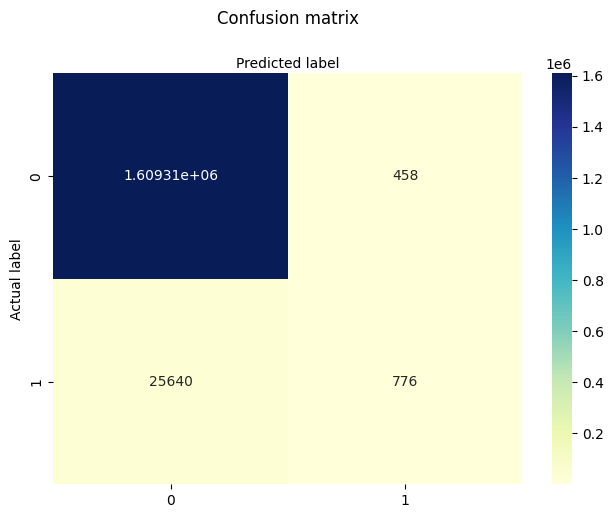

In [12]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [13]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.98      1.00      0.99   1609769
     with IP       0.63      0.03      0.06     26416

    accuracy                           0.98   1636185
   macro avg       0.81      0.51      0.52   1636185
weighted avg       0.98      0.98      0.98   1636185



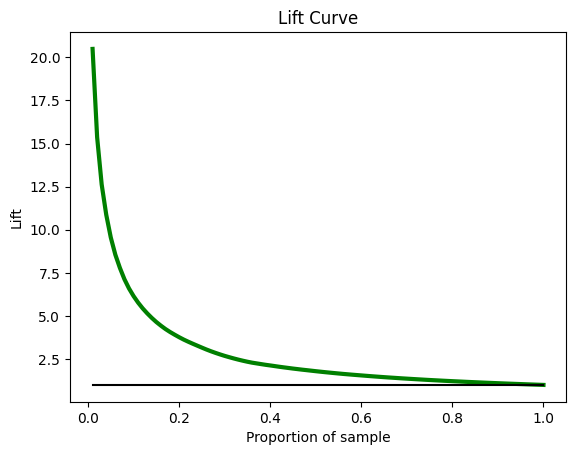

In [14]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


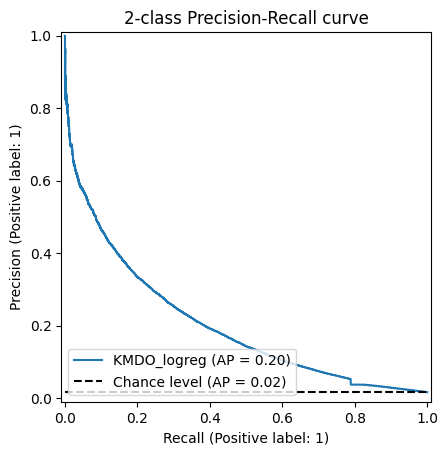

In [15]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [16]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.20087859331931254


In [17]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, y_test, model)
lift_chart.to_csv('lift_chart_xgboost.csv')
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.869630,0.188124,5413,16362,1.000009,20.491369,20.491369,1.000009,20.491181
1,0.188114,0.120947,2707,16362,1.000009,10.247577,30.738946,2.000018,15.369332
2,0.120947,0.089473,1886,16362,1.000009,7.139612,37.878558,3.000028,12.62607
3,0.089471,0.070542,1485,16362,1.000009,5.621593,43.500151,4.000037,10.874938
4,0.070541,0.057903,1125,16362,1.000009,4.258783,47.758934,5.000046,9.551699
...,...,...,...,...,...,...,...,...,...
95,0.001334,0.001256,24,16362,1.000009,0.090854,99.704724,95.999963,1.038591
96,0.001256,0.001170,20,16362,1.000009,0.075712,99.780436,96.999972,1.028665
97,0.001170,0.001069,24,16362,1.000009,0.090854,99.87129,97.999982,1.019095
98,0.001069,0.000936,21,16362,1.000009,0.079497,99.950787,98.999991,1.009604


In [18]:
feature_importances = model.get_booster().get_score(importance_type='weight') 
importance_df = pd.DataFrame(feature_importances.items(), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df)
importance_df.to_csv('importance_df_xgboost.csv')

    Feature  Importance
117  emb240     29586.0
4      emb8     29197.0
46   emb103     27933.0
123  emb251     27168.0
27    emb58     27113.0
..      ...         ...
76   emb155     20248.0
83   emb168     20243.0
37    emb83     20186.0
19    emb39     20110.0
124  emb253     19758.0

[125 rows x 2 columns]


In [19]:
y_pred = model.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)

threshold = 0.3

y_predict_prob =model.predict_proba(X_test)[:, 1]
y_predict_lab = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,1606290,3479
1,23533,2883


In [20]:
y_pred.head()

,acute_ip_flag,y_predict_prob,y_predict_class
asdb_member_key,,,
72348676,0,0.002329,0
351676192,0,0.003068,0
71741818,0,0.010212,0
72825539,0,0.001308,0
281571868,0,0.003434,0


In [21]:
df_out = pd.merge(y_pred, merged, how = 'left',left_index = True, right_index = True)

In [22]:
df_out.head()

,acute_ip_flag_x,y_predict_prob,y_predict_class,coa_population_category,coa_population_group,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,acute_ip_flag_y
asdb_member_key,,,,,,,,,,,,,,,,,,,,,
72348676,0,0.002329,0,Expansion,Expansion,0,0,0,0,0,...,0.590239,0.005441,-0.929826,-0.787461,0.708407,0.607998,-0.051277,-0.734534,-0.877865,0
351676192,0,0.003068,0,Expansion,Expansion,0,0,0,0,0,...,0.649790,0.624598,-0.201417,-1.030866,0.583826,0.452698,-0.550002,-0.947343,0.445912,0
71741818,0,0.010212,0,Expansion,Expansion,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
72825539,0,0.001308,0,Foster,Other,1,1,1,1,0,...,0.645786,0.142041,-0.853042,-0.910185,1.569479,0.482949,-0.343710,-0.834097,-1.076966,0
281571868,0,0.003434,0,TANF,TANF/CHIP,1,1,1,1,0,...,0.506156,0.008412,-1.073015,-1.376985,-0.006690,0.241984,-0.575679,-0.198782,0.044414,0


In [23]:
df_out.shape

(1636203, 564)

In [24]:
m0_3 = df_out.loc[merged['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = df_out.loc[merged['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[merged['tenure_yr1'].isin([9,10,11,12,13,])]

IndexError: Boolean index has wrong length: 1636263 instead of 1636203

In [ ]:
Foster = df_out[df_out['coa_population_category_Foster'] == 1]

Medicare = df_out[df_out['coa_population_category_DSNP Medicare Only'] == 1]

ABD = df_out[(df_out['coa_population_category_DD'] == 1) | 
             (df_out['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = df_out[(df_out['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (df_out['coa_population_category_Dual Elig LTSS'] == 1) |
              (df_out['coa_population_category_Dual Int LTSS'] == 1) |
              (df_out['coa_population_category_LTSS Only'] == 1) ]

Dual = df_out[(df_out['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (df_out['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = df_out[(df_out['coa_population_category_BH Int SMI'] == 1) | 
             (df_out['coa_population_category_BH Only'] == 1)]

Adult = df_out[(df_out['coa_population_category_Expansion'] == 1) | 
             ((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] >= 18)) |
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] >= 18))]

Kid = df_out[((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] < 18)) | 
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] < 18)) ]

In [ ]:
plot_lift_curve(Foster['acute_ip_flag_x'], Foster['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Medicare['acute_ip_flag_x'], Medicare['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(LTSS['acute_ip_flag_x'], LTSS['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Dual['acute_ip_flag_x'], Dual['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(BH['acute_ip_flag_x'], BH['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Adult['acute_ip_flag_x'], Adult['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Kid['acute_ip_flag_x'], Kid['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m0_3['acute_ip_flag_x'], m0_3['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m4_8['acute_ip_flag_x'], m4_8['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m_9_13['acute_ip_flag_x'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
print("% admitted post 6 months ABD: ", ABD['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicare: ", Medicare['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Foster: ", Foster['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicaid Adult: ", Adult['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicaid Kid: ", Kid['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Dual: ", Dual['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months BH: ", BH['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months LTSS: ", LTSS['acute_ip_flag_x'].mean()*100)


In [ ]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

In [ ]:
lift_chart(Foster)

In [ ]:
lift_chart(Medicare)

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)

In [ ]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

In [ ]:
lift_chart(Foster) 

In [ ]:
lift_chart(Medicare)

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)